# 05. 활성화 함수

이번 노트북에서는 sigmoid, tanh, ReLU, softmax를 직접 계산하고 그래프로 봅니다.

공식 암기가 아니라, 입력 숫자가 어떤 모양으로 바뀌는지 보는 것이 목표입니다.

In [1]:
import numpy as np  # 숫자 배열과 수학 계산을 위한 라이브러리입니다.
import matplotlib.pyplot as plt  # 함수 모양을 그래프로 보기 위한 라이브러리입니다.

## 1. sigmoid

sigmoid는 어떤 숫자를 넣어도 0과 1 사이로 바꿉니다.

이진 분류에서 확률처럼 해석할 때 자주 사용합니다.

In [2]:
def sigmoid(x):
    # np.exp()는 자연상수 e의 거듭제곱을 계산하는 함수입니다.
    # 공식은 어려워 보여도, 결과가 0과 1 사이로 나온다는 점이 중요합니다.
    return 1 / (1 + np.exp(-x))

x = np.array([-10, -1, 0, 1, 10], dtype=np.float32)
print("입력:", x)
print("sigmoid 출력:", sigmoid(x))

입력: [-10.  -1.   0.   1.  10.]
sigmoid 출력: [4.539787e-05 2.689414e-01 5.000000e-01 7.310586e-01 9.999546e-01]


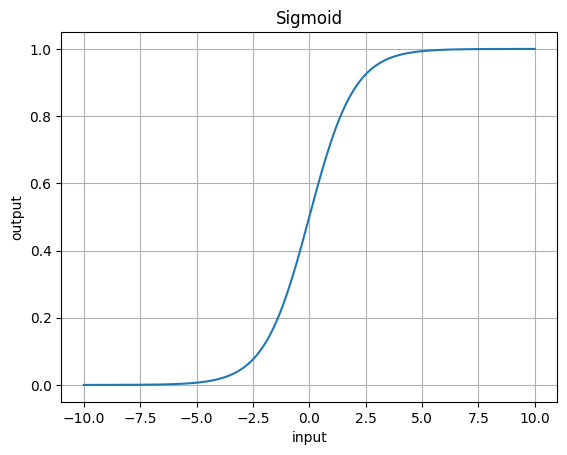

In [3]:
x = np.linspace(-10, 10, 200)  # -10부터 10까지 200개의 숫자를 만듭니다.
y = sigmoid(x)

plt.plot(x, y)
plt.title("Sigmoid")
plt.xlabel("input")
plt.ylabel("output")
plt.grid(True)
plt.show()

## 2. tanh

tanh는 어떤 숫자를 넣어도 -1과 1 사이로 바꿉니다.

값의 중심이 0이라는 특징이 있습니다.

In [4]:
def tanh(x):
    # np.tanh()는 tanh 함수를 계산해주는 numpy 함수입니다.
    return np.tanh(x)

x = np.array([-10, -1, 0, 1, 10], dtype=np.float32)
print("입력:", x)
print("tanh 출력:", tanh(x))

입력: [-10.  -1.   0.   1.  10.]
tanh 출력: [-1.        -0.7615942  0.         0.7615942  1.       ]


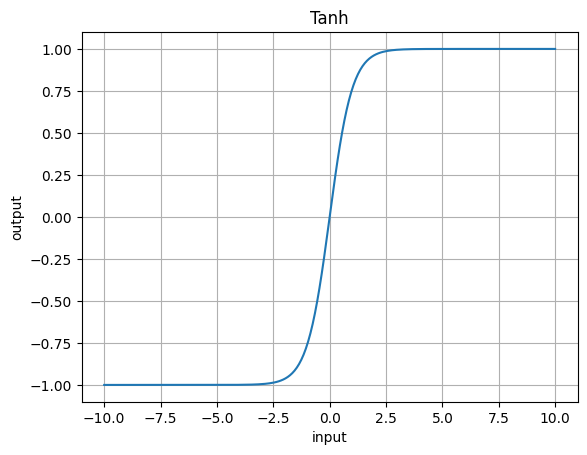

In [5]:
x = np.linspace(-10, 10, 200)
y = tanh(x)

plt.plot(x, y)
plt.title("Tanh")
plt.xlabel("input")
plt.ylabel("output")
plt.grid(True)
plt.show()

## 3. ReLU

ReLU는 음수를 0으로 만들고, 양수는 그대로 통과시킵니다.

In [6]:
def relu(x):
    # np.maximum(0, x)는 0과 x 중 더 큰 값을 고릅니다.
    # x가 음수이면 0이 되고, x가 양수이면 x가 그대로 나옵니다.
    return np.maximum(0, x)

x = np.array([-10, -1, 0, 1, 10], dtype=np.float32)
print("입력:", x)
print("ReLU 출력:", relu(x))

입력: [-10.  -1.   0.   1.  10.]
ReLU 출력: [ 0.  0.  0.  1. 10.]


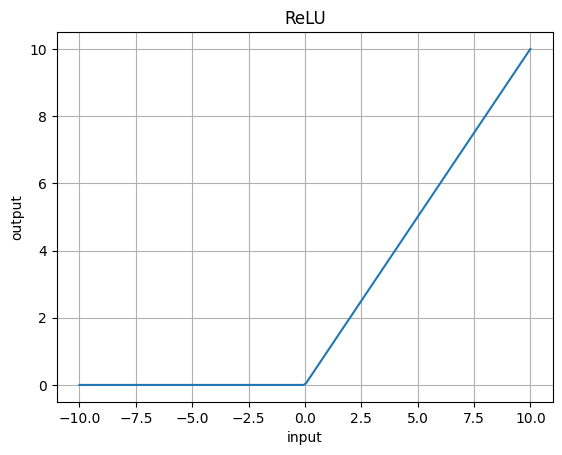

In [7]:
x = np.linspace(-10, 10, 200)
y = relu(x)

plt.plot(x, y)
plt.title("ReLU")
plt.xlabel("input")
plt.ylabel("output")
plt.grid(True)
plt.show()

## 4. softmax

softmax는 여러 점수를 확률처럼 바꿉니다.

출력값은 모두 0과 1 사이이고, 전체 합은 1입니다.

In [8]:
def softmax(scores):
    # exp_scores는 각 점수를 양수 값으로 바꾼 것입니다.
    exp_scores = np.exp(scores)

    # 전체 합으로 나누면 모든 값의 합이 1이 됩니다.
    return exp_scores / np.sum(exp_scores)

scores = np.array([1.0, 2.0, 5.0])
probs = softmax(scores)

print("원래 점수:", scores)
print("softmax 결과:", probs)
print("전체 합:", np.sum(probs))

원래 점수: [1. 2. 5.]
softmax 결과: [0.01714783 0.04661262 0.93623955]
전체 합: 1.0


## 5. 상황별로 고르기

처음에는 아래 정도만 기억하면 됩니다.

```text
이진 분류 출력층: sigmoid
다중 분류 출력층: softmax
은닉층 기본 선택: ReLU
RNN/LSTM 내부에서 자주 만남: tanh
```

In [9]:
situations = {
    "스팸 메일 여부": "sigmoid",
    "꽃 5종류 분류": "softmax",
    "이미지 중간 특징 추출": "ReLU",
    "LSTM 내부 상태 계산": "tanh",
}

for problem, activation in situations.items():
    print(f"{problem} -> {activation}")

스팸 메일 여부 -> sigmoid
꽃 5종류 분류 -> softmax
이미지 중간 특징 추출 -> ReLU
LSTM 내부 상태 계산 -> tanh


## 정리

활성화 함수는 모델의 숫자를 문제 목적에 맞게 바꿔주는 장치입니다.

이번 장에서는 결과의 범위와 용도를 중심으로 기억하면 됩니다.

## 과제

1. `[-5, -1, 0, 2, 10]`에 ReLU를 적용한 값을 직접 계산해보세요.
2. sigmoid 출력이 0.9라면 이진 분류에서 어떻게 해석할 수 있을까요?
3. 꽃 5종류 분류에는 sigmoid와 softmax 중 무엇이 더 어울릴까요?
4. softmax 결과의 합이 1인지 다른 점수로 확인해보세요.